# Pipeline Pengolahan Data Resep Cookpad & Knowledge Base Ingredients
**Project:** Jivara (CC26-PSU090) — Sistem Deteksi Interaksi Obat-Makanan
**Role:** Data Science (Rizki Pangestu)

Pipeline ini memproses dataset resep makanan Indonesia dari Cookpad 
(6 kelas awal + 55 kelas tambahan) menjadi artefak siap pakai untuk analisis, 
dan membangun Ingredient Knowledge Base yang memetakan kelas makanan ke bahan penyusunnya.

## Pertanyaan Bisnis

1. **Bagaimana distribusi resep berdasarkan 61 kelas makanan YOLO?** Apakah dataset kita sudah mencakup keseluruhan target kelas deteksi?
2. **Apa saja bahan-bahan (ingredients) inti yang paling dominan di setiap kelas makanan?**
3. **Bagaimana sebaran kompleksitas resep (jumlah bahan & langkah) antar kelas?** 
4. **Bagaimana cara memetakan (mapping) kelas makanan hasil deteksi YOLO menjadi sekumpulan bahan makanan untuk input deteksi interaksi obat?**

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
import json
import emoji
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR = Path('..')
RAW_DIR = BASE_DIR / 'Scraping'
OUTPUT_DIR = BASE_DIR / 'data_output'

for subdirectory in ['processed', 'for_backend', 'docs']:
    (OUTPUT_DIR / subdirectory).mkdir(parents=True, exist_ok=True)

print("Library dan direktori siap.")

Library dan direktori siap.


---
## 2. Data Wrangling — Menggabungkan 2 Dataset Resep

Kita memiliki 2 dataset:
1. `cookpad_resep_makanan.csv` (6 kelas awal: nasi goreng, soto ayam, dll)
2. `resep_55_kelas_makanan.csv` (55 kelas tambahan hasil scraping khusus)

In [2]:
# Load Dataset 1 (6 Kelas)
df1 = pd.read_csv(RAW_DIR / 'cookpad_resep_makanan.csv')
df1['Kelas_YOLO'] = df1['Kategori'].str.lower().str.replace(' ', '-')
print(f"Dataset 1 Shape: {df1.shape}")

# Load Dataset 2 (55 Kelas Tambahan)
df2 = pd.read_csv(RAW_DIR / 'resep_55_kelas_makanan.csv')
df2['Kelas_YOLO'] = df2['Kelas_YOLO'].str.lower()
print(f"Dataset 2 Shape: {df2.shape}")

# Kolom yang akan diambil
cols = ['Nama Resep', 'Kelas_YOLO', 'Deskripsi', 'Bahan-bahan', 'Langkah Memasak', 'Waktu Memasak', 'Jumlah Porsi', 'URL']

# Pastikan kedua dataframe memiliki kolom yang sama
df1_clean = df1[[c for c in cols if c in df1.columns]].copy()
df2_clean = df2[[c for c in cols if c in df2.columns]].copy()

# Gabungkan
resep_raw = pd.concat([df1_clean, df2_clean], ignore_index=True)
print(f"\nDataset Gabungan Shape: {resep_raw.shape}")
print(f"Total Kelas Unik: {resep_raw['Kelas_YOLO'].nunique()} kelas")

Dataset 1 Shape: (500, 14)
Dataset 2 Shape: (550, 15)

Dataset Gabungan Shape: (1050, 8)
Total Kelas Unik: 61 kelas


### 2.2 Cleaning Data

In [3]:
resep = resep_raw.copy()

# 1. Bersihkan HTML entities & Hapus Emoji
def clean_text(text):
    if pd.isna(text): return text
    # Hapus HTML entities
    text = html.unescape(str(text))
    # Hapus Emoji
    text = emoji.replace_emoji(text, replace='')
    # Hapus whitespace berlebih yang mungkin tersisa
    return " ".join(text.split())

for col in resep.select_dtypes(include='object').columns:
    resep[col] = resep[col].apply(clean_text)

# 2. Hapus duplikat berdasarkan URL
before_dedup = len(resep)
resep.drop_duplicates(subset=['URL'], inplace=True)
after_dedup = len(resep)
print(f"Baris dihapus (duplikat URL): {before_dedup - after_dedup}")

# 3. Standarisasi Waktu Memasak → menit
def parse_waktu(text):
    if pd.isna(text): return np.nan
    text = str(text).lower().strip()
    total = 0
    jam_match = re.search(r'(\d+)\s*jam', text)
    menit_match = re.search(r'(\d+)\s*menit', text)
    if jam_match: total += int(jam_match.group(1)) * 60
    if menit_match: total += int(menit_match.group(1))
    if total == 0:
        angka = re.findall(r'(\d+)', text)
        if angka:
            total = int(angka[0]) * 60 if 'jam' in text else int(angka[0])
    return total if total > 0 else np.nan

resep['Waktu_Menit'] = resep['Waktu Memasak'].apply(parse_waktu)

# 4. Standarisasi Jumlah Porsi → numerik
def parse_porsi(text):
    if pd.isna(text): return np.nan
    angka = re.findall(r'(\d+)', str(text))
    return int(angka[0]) if angka else np.nan

resep['Porsi_Numerik'] = resep['Jumlah Porsi'].apply(parse_porsi)

# 5. Parsing Bahan → list
def parse_bahan(text):
    if pd.isna(text): return []
    return [b.strip() for b in text.split('|') if b.strip()]

resep['List_Bahan'] = resep['Bahan-bahan'].apply(parse_bahan)

# 6. Parsing Langkah → list
def parse_langkah(text):
    if pd.isna(text): return []
    return [l.strip() for l in text.split('||') if l.strip()]

resep['List_Langkah'] = resep['Langkah Memasak'].apply(parse_langkah)

print(f"Shape final setelah cleaning: {resep.shape}")

Baris dihapus (duplikat URL): 0
Shape final setelah cleaning: (1050, 12)


---
## 3. Feature Engineering

In [4]:
# Hitung jumlah bahan & langkah
resep['Jumlah_Bahan'] = resep['List_Bahan'].apply(len)
resep['Jumlah_Langkah'] = resep['List_Langkah'].apply(len)

# Label kompleksitas
def label_kompleksitas(row):
    if row['Jumlah_Bahan'] <= 7: return 'Sederhana'
    elif row['Jumlah_Bahan'] <= 14: return 'Menengah'
    else: return 'Kompleks'

resep['Kompleksitas'] = resep.apply(label_kompleksitas, axis=1)
print("Feature engineering selesai.")

Feature engineering selesai.


---
## 4. Ekstraksi Bahan & Pembuatan Knowledge Base (MAPPING Makanan -> Bahan)

Bagian ini menjawab request untuk memetakan nama makanan (class YOLO) menjadi daftar bahan/ingredients.
Misal: `nasi-goreng` -> `["nasi putih", "bawang putih", "telur", ...]`

In [5]:
def extract_nama_bahan(text):
    """Ambil nama bahan, hilangkan kuantitas (1 sdm, 250gr, dst)."""
    text = re.sub(r'^[\d\s,./]+', '', text).strip()
    text = re.sub(r'^(sdm|sdt|gram|gr|kg|ml|liter|buah|butir|siung|lembar|batang|ruas|porsi|piring|mangkok|bungkus|sachet|secukupnya|sejumput|sesuai selera)\s*', '', text, flags=re.IGNORECASE).strip()
    return text.lower() if text else None

# Buat Knowledge Base Dictionary
ingredient_kb = {}

# Proses per kelas makanan
for kelas in resep['Kelas_YOLO'].unique():
    # Ambil semua resep untuk kelas ini
    df_kelas = resep[resep['Kelas_YOLO'] == kelas]
    
    # Flatten semua bahan
    all_bahan_kelas = df_kelas['List_Bahan'].explode()
    all_bahan_kelas = all_bahan_kelas[all_bahan_kelas.str.len() > 0]
    
    # Bersihkan nama bahan
    bahan_names = all_bahan_kelas.apply(extract_nama_bahan).dropna()
    
    # Hitung frekuensi tiap bahan
    bahan_counts = bahan_names.value_counts()
    
    # Ambil bahan utama (muncul di minimal 20% resep, maksimal 15 bahan)
    threshold = max(2, len(df_kelas) * 0.20)
    top_bahan = bahan_counts[bahan_counts >= threshold].head(15).index.tolist()
    
    # Jika tidak ada yang lewat threshold, ambil top 5 saja
    if not top_bahan:
        top_bahan = bahan_counts.head(5).index.tolist()
        
    ingredient_kb[kelas] = top_bahan

print(f"Berhasil membuat mapping bahan untuk {len(ingredient_kb)} kelas makanan.")
print("\nContoh Mapping:")
for k in ['nasi-goreng', 'rendang', 'ayam-goreng-lengkuas']:
    if k in ingredient_kb:
        print(f"  - {k}: {ingredient_kb[k]}")

Berhasil membuat mapping bahan untuk 61 kelas makanan.

Contoh Mapping:
  - nasi-goreng: ['garam', 'bawang putih', 'bawang merah', 'telur', 'kecap manis', 'saus tiram', 'kecap asin', 'minyak goreng', 'nasi']
  - rendang: ['garam', 'bawang putih', 'bawang merah', 'daun salam', 'daun jeruk', 'air', 'daging sapi', 'kemiri', 'jahe', 'ketumbar', 'lengkuas']
  - ayam-goreng-lengkuas: ['bawang putih', 'bawang merah', 'daun salam', 'garam', 'daun jeruk', 'kemiri', 'ketumbar', 'lengkuas', 'merica', 'cm kunyit', 'merica bubuk', 'cm jahe', 'bumbu halus :', 'ayam', 'air']


---
## 5. Exploratory Data Analysis (EDA)

C:\Users\risky\AppData\Local\Temp\ipykernel_22460\354310235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_kelas.values, y=top_kelas.index, ax=axes[0], palette="viridis")


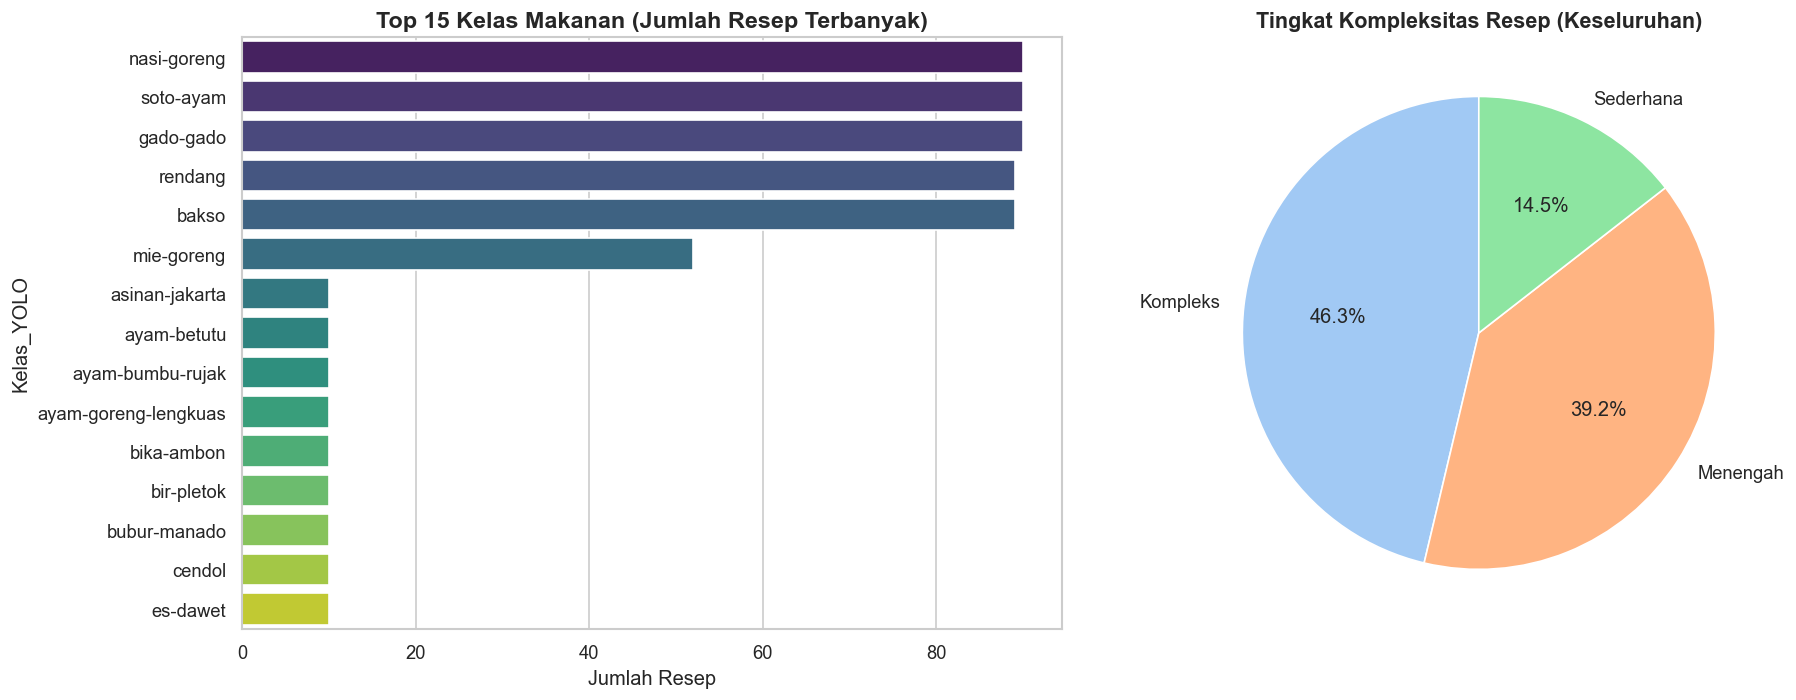

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Kelas dengan Resep Terbanyak
top_kelas = resep['Kelas_YOLO'].value_counts().head(15)
sns.barplot(x=top_kelas.values, y=top_kelas.index, ax=axes[0], palette="viridis")
axes[0].set_xlabel('Jumlah Resep')
axes[0].set_title('Top 15 Kelas Makanan (Jumlah Resep Terbanyak)', fontsize=14, fontweight='bold')

# Pie chart kompleksitas
kompleks_counts = resep['Kompleksitas'].value_counts()
kompleks_counts.plot.pie(autopct='%1.1f%%', ax=axes[1],
                          colors=sns.color_palette("pastel", 3), startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Tingkat Kompleksitas Resep (Keseluruhan)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Export Artefak

In [7]:
# 1. Export Data Resep Cleaned
export_cols = ['Nama Resep', 'Kelas_YOLO', 'Deskripsi', 'Bahan-bahan', 'Jumlah_Bahan',
               'Langkah Memasak', 'Jumlah_Langkah', 'Waktu_Menit', 'Porsi_Numerik',
               'URL', 'Kompleksitas']
output_resep = OUTPUT_DIR / 'processed' / '61_kelas_resep_cleaned.csv'
resep[export_cols].to_csv(output_resep, index=False)
print(f"Exported: {output_resep} ({len(resep)} rows)")

# 2. Export Knowledge Base (JSON) -> SANGAT PENTING UNTUK AI ENGINEER
output_json = OUTPUT_DIR / 'for_ai_engineer' / 'food_to_ingredient_kb.json'
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump({
        "metadata": {
            "version": "1.0",
            "total_classes": len(ingredient_kb),
            "description": "Mapping 61 YOLO Food Classes to their typical ingredients for drug interaction rule engine."
        },
        "food_to_ingredients": ingredient_kb
    }, f, indent=4, ensure_ascii=False)
print(f"Exported: {output_json} (Knowledge Base file for AI Engineer)")

# 3. Export Mapping ke CSV (Untuk analisis tabular)
mapping_rows = []
for k, v in ingredient_kb.items():
    mapping_rows.append({'Kelas_YOLO': k, 'Bahan_Penyusun': ", ".join(v)})
df_mapping = pd.DataFrame(mapping_rows)
output_mapping = OUTPUT_DIR / 'processed' / 'food_ingredient_mapping.csv'
df_mapping.to_csv(output_mapping, index=False)
print(f"Exported: {output_mapping}")

print("\nPipeline Selesai!")

Exported: ..\data_output\processed\61_kelas_resep_cleaned.csv (1050 rows)
Exported: ..\data_output\for_ai_engineer\food_to_ingredient_kb.json (Knowledge Base file for AI Engineer)
Exported: ..\data_output\processed\food_ingredient_mapping.csv

Pipeline Selesai!
